# Customer Churn Analysis - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to analyze customer behavior and identify key factors influencing customer churn using statistical summaries and visualizations.

### 1. Import Required Libraries

Import the libraries required for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the Cleaned Dataset

Load the cleaned dataset prepared in the previous notebook.

In [3]:
df = pd.read_csv("C:/Users/Asus/OneDrive/Desktop/Customer_Churn_Analysis/Dataset/customer_churn_cleaned.csv")

### 3. Univariate Analysis

Analyze the distribution of individual variables to understand customer demographics and service characteristics.

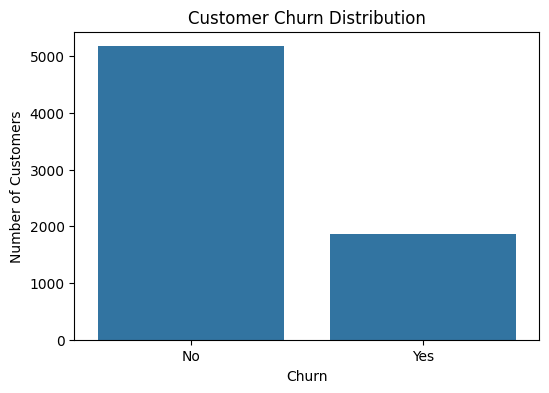

In [4]:
#customer churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- The dataset contains more retained customers than churned customers.
- Customer churn is imbalanced, indicating that classification metrics such as Precision, Recall, and F1-score will be important during model evaluation.

## 4. Churn Analysis by Gender

### Business Question
Does customer churn differ between male and female customers?

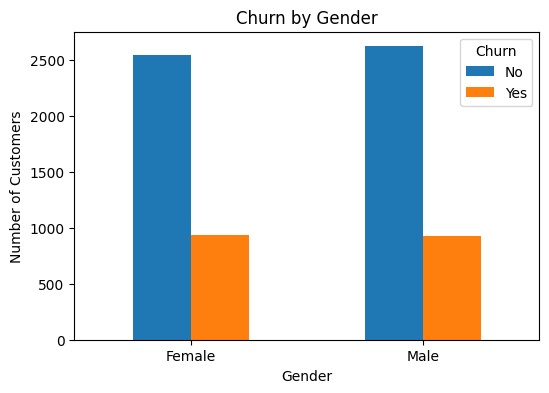

In [5]:
gender_churn = pd.crosstab(df['gender'], df['Churn'])

gender_churn.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Insight

- Customer churn is distributed fairly evenly across both genders.
- Gender alone does not appear to be a strong predictor of churn.

## 5. Churn Analysis by Contract Type

### Business Question

Which contract type experiences the highest customer churn?

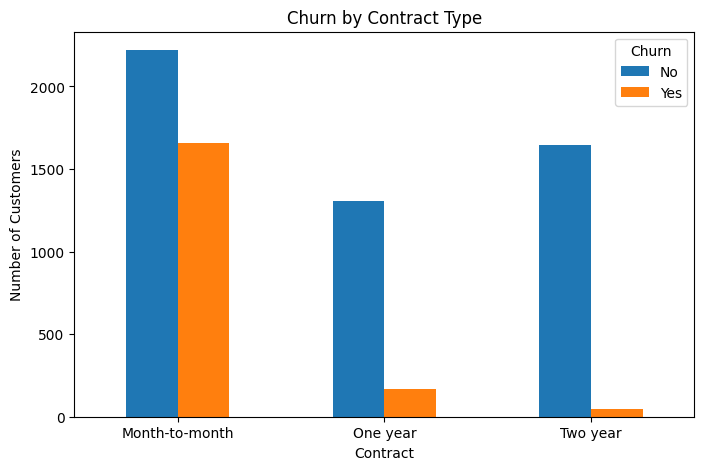

In [6]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])

contract_churn.plot(kind='bar', figsize=(8,5))

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Insight

- Customers with month-to-month contracts have the highest churn.
- Longer-term contracts show significantly better customer retention.

## 6. Churn Analysis by Internet Service

### Business Question

Does the type of internet service affect customer churn?

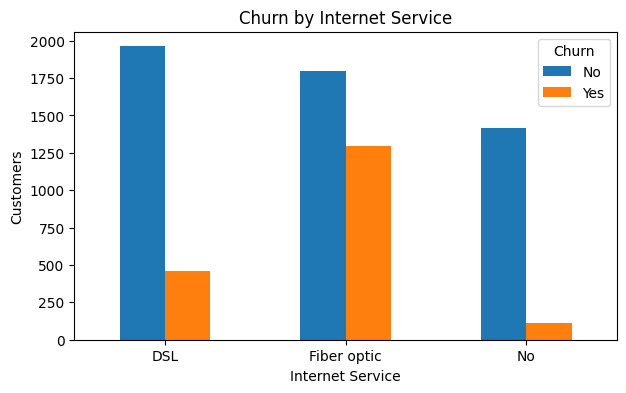

In [7]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])

internet_churn.plot(kind='bar', figsize=(7,4))
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

### Insight

- Fiber optic customers exhibit higher churn compared to DSL customers.
- This may indicate pricing, service quality, or customer expectation issues.

## 7. Churn Analysis by Payment Method

### Business Question

Does the payment method influence customer churn?

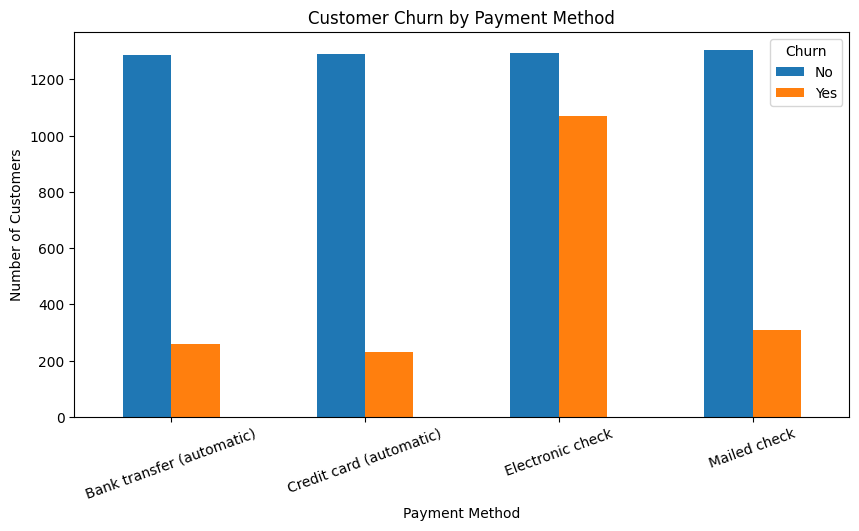

In [8]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])

payment_churn.plot(kind='bar', figsize=(10,5))

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

### Insight

- Customers using electronic checks exhibit the highest churn.
- Customers using automatic payment methods tend to have lower churn.
- Encouraging customers to switch to automatic payment options may improve customer retention.

## 8. Customer Tenure Distribution

### Business Question

How long have customers stayed with the company?

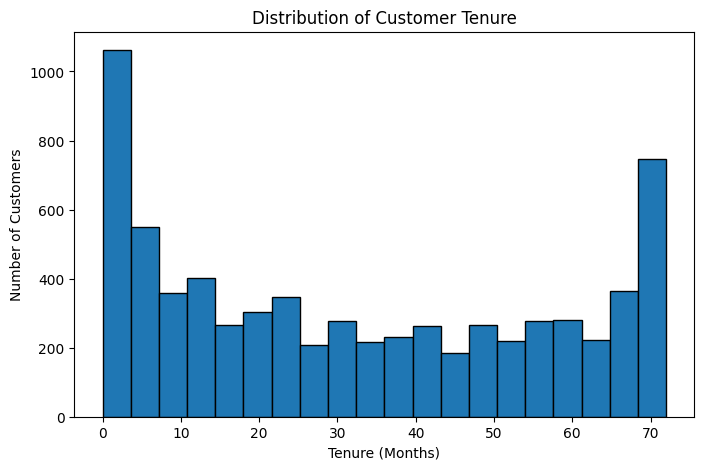

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['tenure'], bins=20, edgecolor='black')

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- The dataset includes both new and long-term customers.
- A significant number of customers have relatively short tenures.
- Understanding customer tenure is important because new customers are generally at a higher risk of churning.

## 9. Monthly Charges Distribution

### Business Question

How are monthly charges distributed among customers?

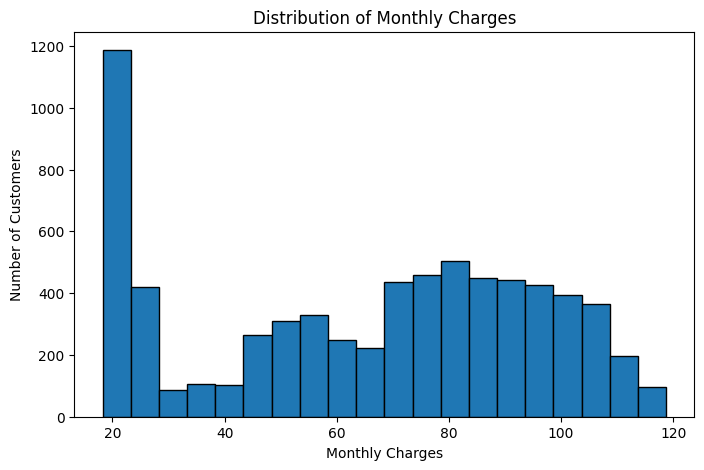

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['MonthlyCharges'], bins=20, edgecolor='black')

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- Monthly charges vary considerably across customers.
- Most customers fall within the low to medium monthly charge range.
- This distribution provides an overview of the company's pricing structure.

## 10. Monthly Charges by Churn Status

### Business Question

Are customers with higher monthly charges more likely to churn?

<Figure size 800x500 with 0 Axes>

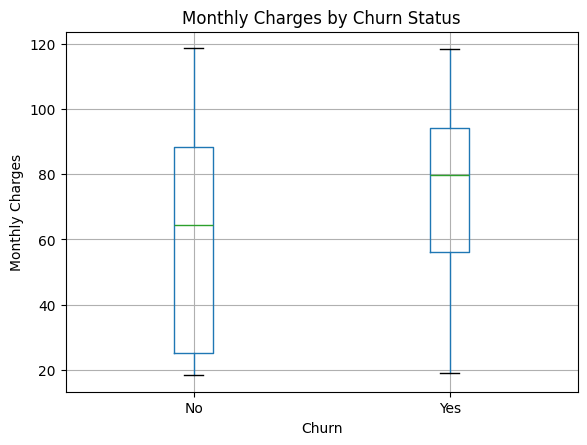

In [11]:
plt.figure(figsize=(8,5))

df.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Insight

- Churned customers generally have higher monthly charges than retained customers.
- Higher subscription costs may contribute to customer dissatisfaction.
- Pricing strategies and promotional offers could help reduce churn among high-paying customers.

## 11. Total Charges by Churn Status

### Business Question

How do total charges differ between churned and retained customers?

<Figure size 800x500 with 0 Axes>

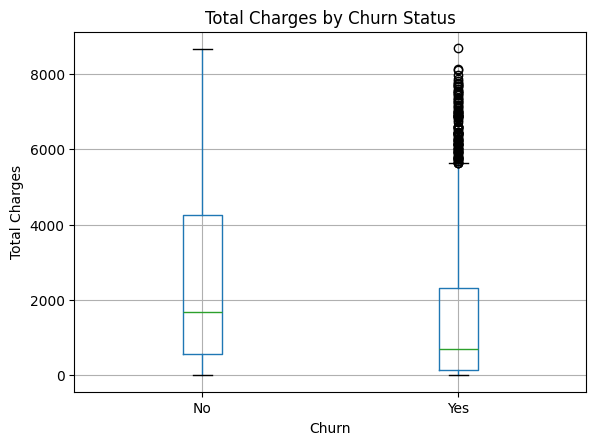

In [12]:
plt.figure(figsize=(8,5))

df.boxplot(column='TotalCharges', by='Churn')

plt.title("Total Charges by Churn Status")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

### Insight

- Retained customers generally have higher total charges because they stay with the company longer.
- Churned customers often have lower total charges due to shorter tenure.
- Increasing customer retention can significantly improve customer lifetime value.

## 12. Correlation Analysis

### Business Question

What relationships exist among the numerical features in the dataset?

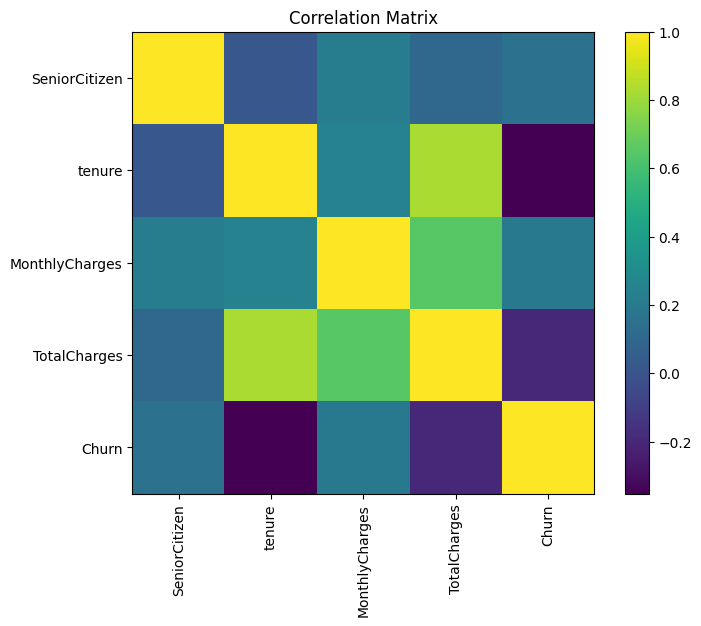

In [13]:
eda_df = df.copy()

eda_df["Churn"] = eda_df["Churn"].map({"Yes": 1, "No": 0})

correlation = eda_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

### Insight

- Customer tenure has a negative relationship with churn, suggesting that long-term customers are less likely to leave.
- Monthly charges have a stronger relationship with churn than total charges.
- The correlation matrix helps identify useful variables for building the churn prediction model.

# Key Business Insights

- Month-to-month contracts have the highest customer churn.
- Customers using fiber optic internet services are more likely to churn.
- Electronic check is associated with higher churn than other payment methods.
- Customers with higher monthly charges are more likely to leave the company.
- Long-term customers are significantly less likely to churn.
- Gender has little impact on customer churn.
- Retention strategies should focus on new customers, customers on month-to-month contracts, and customers with higher monthly charges.